In [1]:
# Install required libraries (run once)
!pip install matplotlib seaborn nltk wordcloud textblob

import sys
!{sys.executable} -m pip install wordcloud


# Import core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & text processing
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer

# Download required NLTK datasets
nltk.download('vader_lexicon')
nltk.download('stopwords')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
## TODO 2 : Load, clean and preprocess the raw review data from the CSV file.
df = pd.read_csv("https://gitlab.crio.do/me_notebook/me_jupyter_amazonfeedbackanalysis/-/raw/master/amazon_product_reviews.csv")


# Preview
print("Shape:", df.shape)
print(df.head())

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace('.', '_')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert date column
df['reviews_dateadded'] = pd.to_datetime(df['reviews_dateadded'], errors='coerce')

# Convert review rating to numeric
df['reviews_rating'] = pd.to_numeric(df['reviews_rating'], errors='coerce')

# Map recommend column
df['reviews_dorecommend'] = df['reviews_dorecommend'].map({'Yes': True, 'No': False})

# Fill missing values
df['reviews_numhelpful'] = df['reviews_numhelpful'].fillna(0).astype(int)
df['reviews_text'] = df['reviews_text'].fillna("")
df['reviews_title'] = df['reviews_title'].fillna("")
df['reviews_username'] = df['reviews_username'].fillna("Anonymous")

# Drop rows with no rating
df = df[df['reviews_rating'].notnull()]

Shape: (3077, 13)
                     id                                               name  \
0  AVqVGZO3nnc1JgDc3jGK  Kindle Oasis E-reader with Leather Charging Co...   
1  AVqVGZO3nnc1JgDc3jGK  Kindle Oasis E-reader with Leather Charging Co...   
2  AVqVGZO3nnc1JgDc3jGK  Kindle Oasis E-reader with Leather Charging Co...   
3  AVqVGZO3nnc1JgDc3jGK  Kindle Oasis E-reader with Leather Charging Co...   
4  AVqVGZO3nnc1JgDc3jGK  Kindle Oasis E-reader with Leather Charging Co...   

        asins   brand                                        categories1  \
0  B00VINDBJK  Amazon  eBook Readers,Kindle E-readers,Computers & Tab...   
1  B00VINDBJK  Amazon  eBook Readers,Kindle E-readers,Computers & Tab...   
2  B00VINDBJK  Amazon  eBook Readers,Kindle E-readers,Computers & Tab...   
3  B00VINDBJK  Amazon  eBook Readers,Kindle E-readers,Computers & Tab...   
4  B00VINDBJK  Amazon  eBook Readers,Kindle E-readers,Computers & Tab...   

                                categories2     reviews.

/tmp/ipython-input-3037481592.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reviews_rating', data=df, palette='Blues')


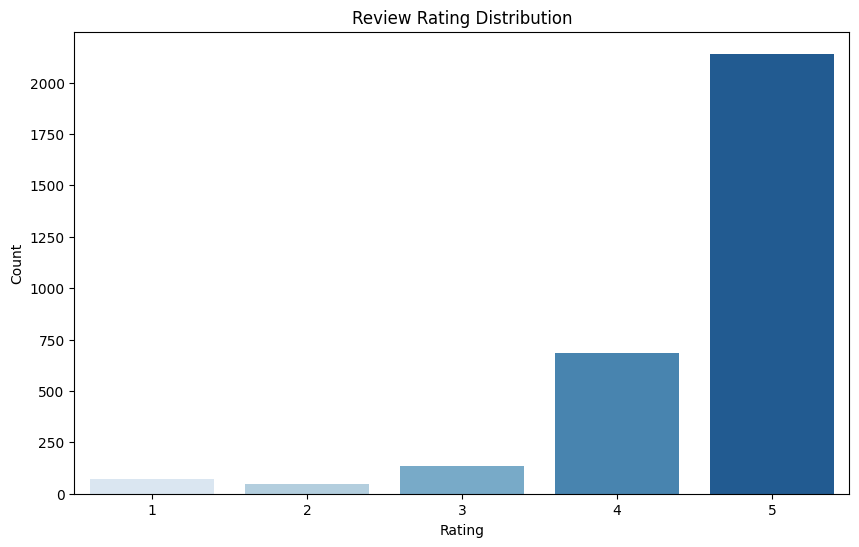

/tmp/ipython-input-3037481592.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reviews_dorecommend', data=df, palette='Set2')
/tmp/ipython-input-3037481592.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(x='reviews_dorecommend', data=df, palette='Set2')


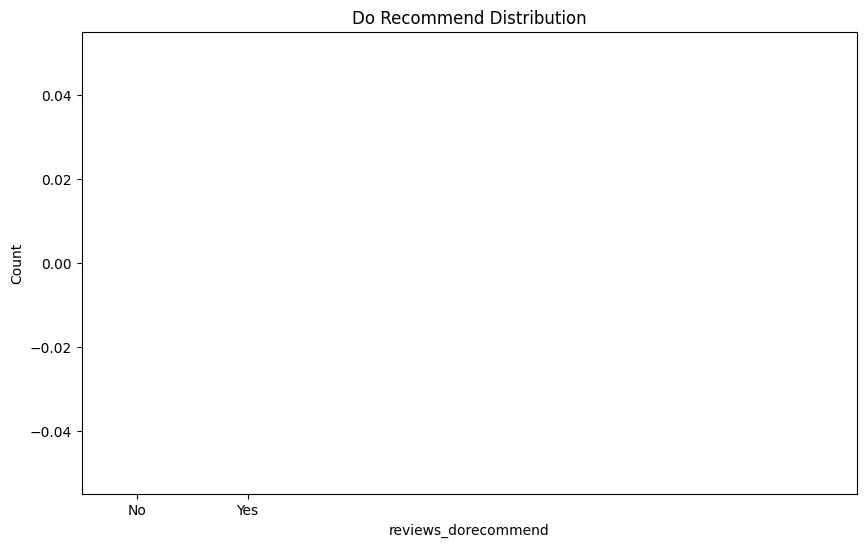

/tmp/ipython-input-3037481592.py:26: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['reviews_dateadded'].dt.to_period("M")


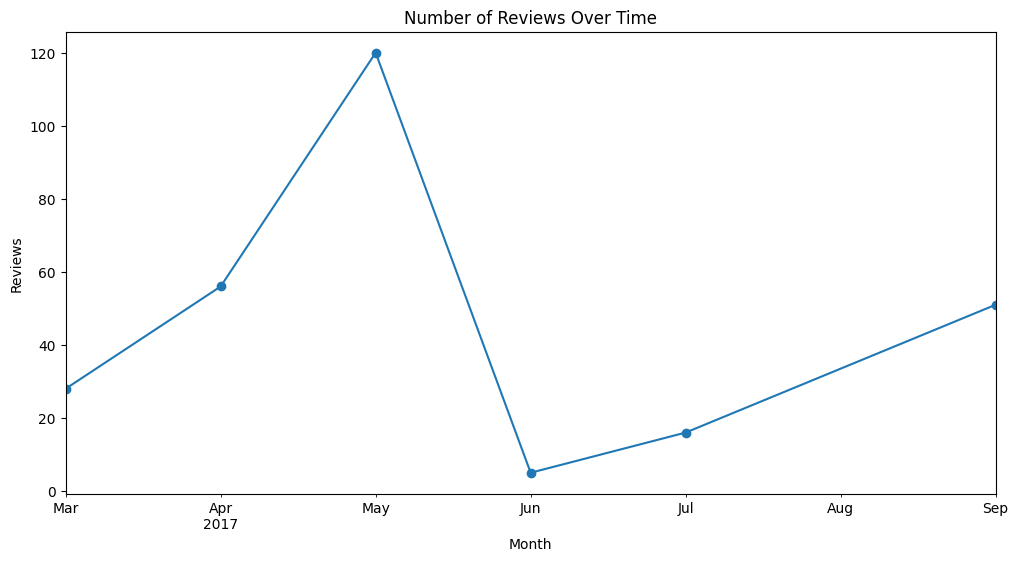

/tmp/ipython-input-3037481592.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='reviews_rating', y='reviews_numhelpful', data=df, palette='coolwarm')


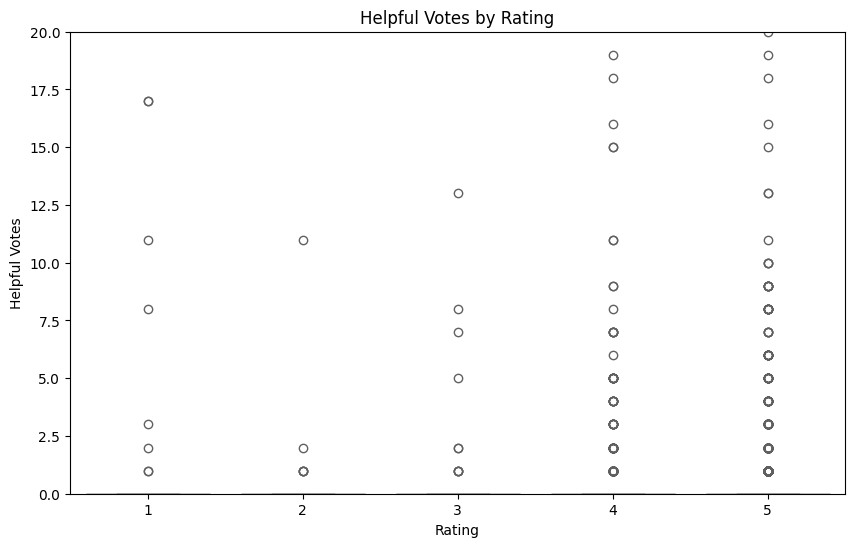

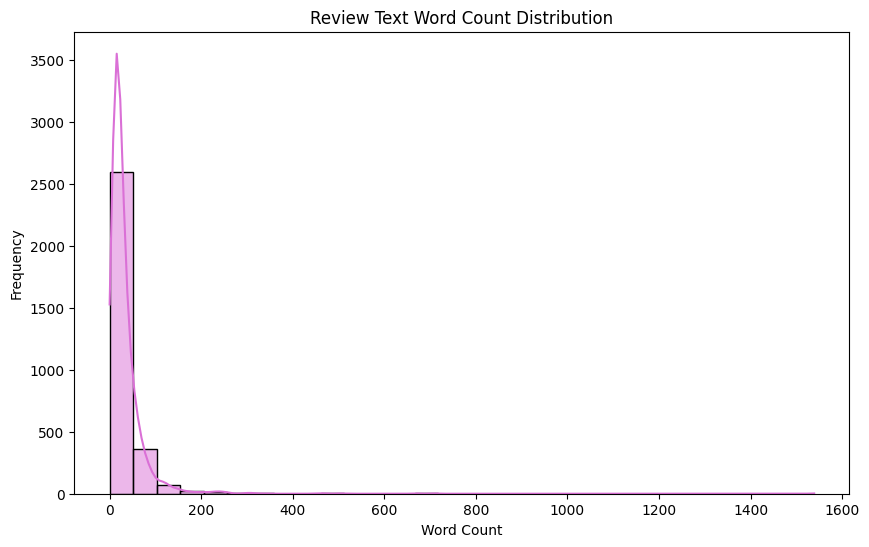

In [3]:
## TODO 3 : Perform exploratory data analysis (EDA) and visualize key trends using Matplotlib/Seaborn.
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Review Rating Distribution ---
plt.figure(figsize=(10, 6))
sns.countplot(x='reviews_rating', data=df, palette='Blues')
plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# --- 2. Do Recommend Distribution ---
plt.figure(figsize=(10, 6))
sns.countplot(x='reviews_dorecommend', data=df, palette='Set2')
plt.title("Do Recommend Distribution")
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel("Count")
plt.show()

# --- 3. Reviews Over Time ---
# Make sure 'reviews_dateadded' is in datetime format
df['reviews_dateadded'] = pd.to_datetime(df['reviews_dateadded'], errors='coerce')

# Extract month
df['month'] = df['reviews_dateadded'].dt.to_period("M")

# Plot
df['month'].value_counts().sort_index().plot(kind='line', marker='o', figsize=(12, 6))
plt.title("Number of Reviews Over Time")
plt.xlabel("Month")
plt.ylabel("Reviews")
plt.xticks(rotation=45)
plt.show()

# --- 4. Helpful Votes by Rating ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='reviews_rating', y='reviews_numhelpful', data=df, palette='coolwarm')
plt.title("Helpful Votes by Rating")
plt.ylim(0, 20)
plt.xlabel("Rating")
plt.ylabel("Helpful Votes")
plt.show()

# --- 5. Review Text Word Count Distribution ---
df['review_length'] = df['reviews_text'].fillna("").astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=30, kde=True, color='orchid')
plt.title("Review Text Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


sentiment
Positive    2484
Neutral      500
Negative      93
Name: count, dtype: int64


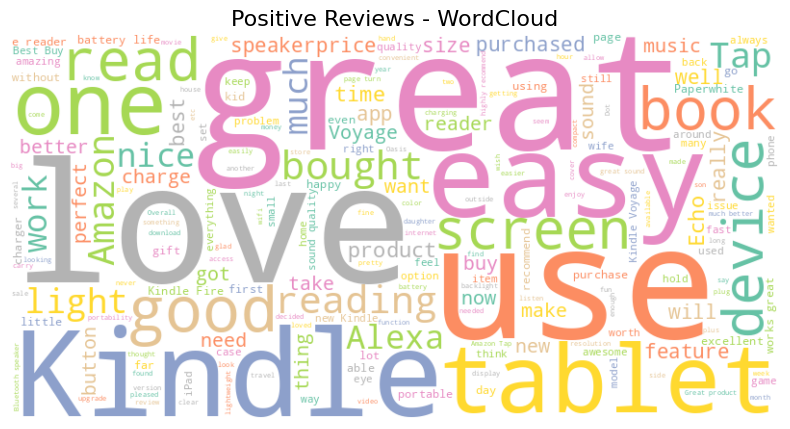

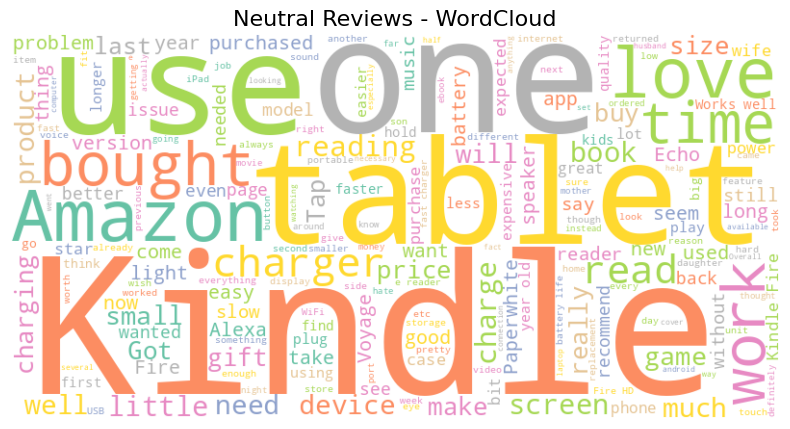

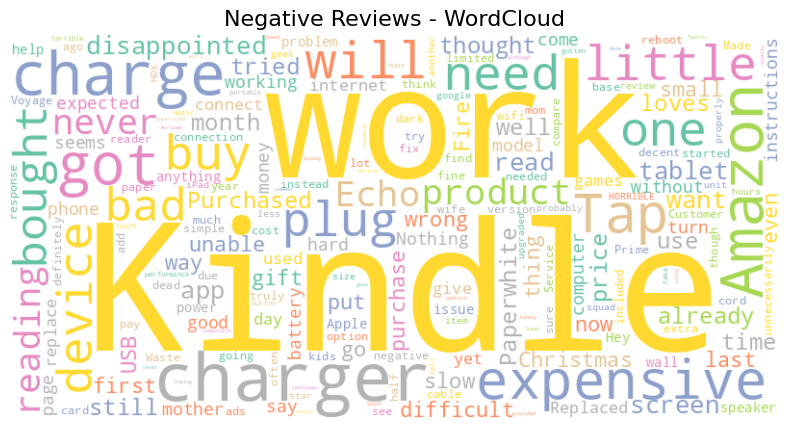

In [4]:
## TODO 4 : Do sentiment/text analysis on feedback column using prompts and create a wordcloud for the most repeated feedback.
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from wordcloud import WordCloud

# Clean and prepare text
df['reviews_text'] = df['reviews_text'].fillna("").astype(str)

# Sentiment function
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment
df['sentiment'] = df['reviews_text'].apply(get_sentiment)

# Summary
print(df['sentiment'].value_counts())

# WordCloud function
def generate_wordcloud(text, title):
    if text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"{title} - WordCloud", fontsize=16)
        plt.axis('off')
        plt.show()
    else:
        print(f"No reviews available for {title}")

# Combine review text by sentiment
positive_text = " ".join(df[df['sentiment'] == 'Positive']['reviews_text'])
neutral_text = " ".join(df[df['sentiment'] == 'Neutral']['reviews_text'])
negative_text = " ".join(df[df['sentiment'] == 'Negative']['reviews_text'])

# Generate WordClouds
generate_wordcloud(positive_text, "Positive Reviews")
generate_wordcloud(neutral_text, "Neutral Reviews")
generate_wordcloud(negative_text, "Negative Reviews")

/tmp/ipython-input-1226044727.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_df, x='count', y='word', palette='Reds_r')


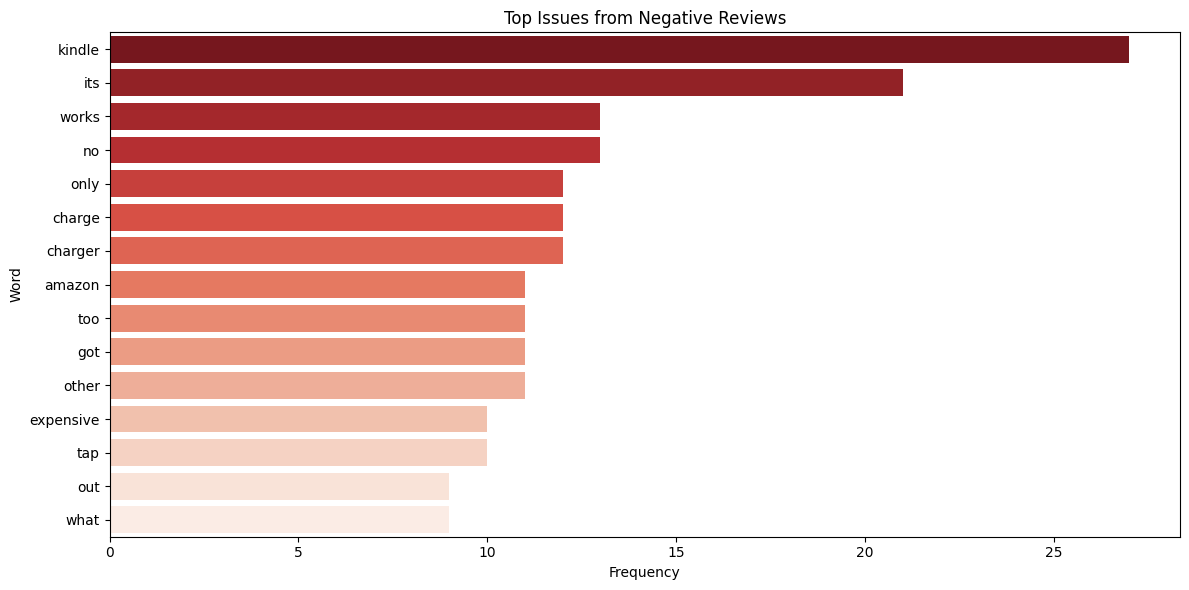

/tmp/ipython-input-1226044727.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=['Positive', 'Neutral', 'Negative'], palette='Set2')


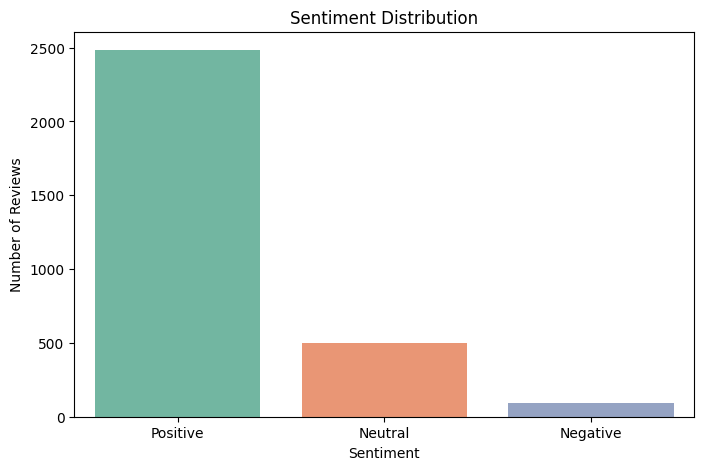

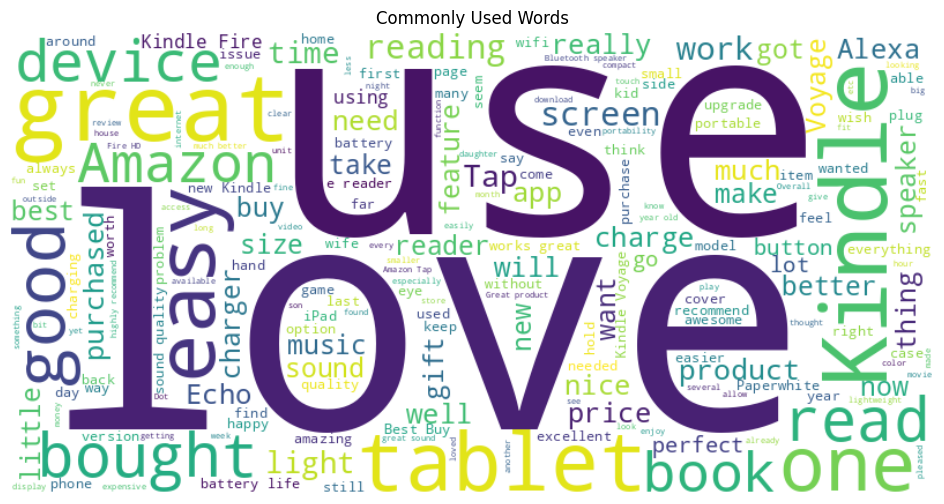

In [5]:
## TODO 5 : Creat a barplot showing the most frequent words in negative reviews
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from textblob import TextBlob
from wordcloud import WordCloud

# Ensure reviews_text is clean
df['reviews_text'] = df['reviews_text'].fillna("").astype(str)

# Define sentiment function
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['sentiment'] = df['reviews_text'].apply(get_sentiment)

# Filter negative reviews
negative_reviews = df[df['sentiment'] == 'Negative']['reviews_text']

# Clean and tokenize text
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text.lower())  # Remove punctuation and lowercase
    words = text.split()
    stopwords = set([
        'the', 'and', 'i', 'to', 'it', 'was', 'is', 'this', 'for', 'of', 'in', 'on', 'my',
        'but', 'with', 'that', 'a', 'not', 'have', 'had', 'so', 'be', 'as', 'at', 'very',
        'were', 'they', 'you', 'we', 'are', 'me', 'from', 'when', 'just', 'if', 'or', 'an'
    ])
    return [word for word in words if word not in stopwords]

# Process and count word frequencies
all_words = []
for review in negative_reviews:
    all_words.extend(preprocess_text(review))

word_freq = Counter(all_words)
top_words = word_freq.most_common(15)

# Create DataFrame for plotting
freq_df = pd.DataFrame(top_words, columns=['word', 'count'])

# Plot top issues from negative reviews
plt.figure(figsize=(12, 6))
sns.barplot(data=freq_df, x='count', y='word', palette='Reds_r')
plt.title("Top Issues from Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', order=['Positive', 'Neutral', 'Negative'], palette='Set2')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# Join all reviews and generate wordcloud
all_text = " ".join(df['reviews_text'].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Commonly Used Words")
plt.axis('off')
plt.show()